In [8]:
# ==============================================================================
# MASTER NOTEBOOK: AIRLINE ROUTE CLUSTERING ANALYSIS
# ==============================================================================
# Author: Guilherme F Dellatin (Expert Data Scientist Persona)
# Context: Consolidates best practices from previous iterations (v1, v2, v3)
# Objective: Segment airline routes to identify operational patterns using K-Means.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

# Configuration for cleaner output
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_context("notebook", font_scale=1.1)

In [9]:
# ==============================================================================
# 1. DATA LOADING & PREPROCESSING
# ==============================================================================
print("Loading dataset...")
cols = ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT','DEPARTURE_DELAY', 'DISTANCE','CANCELLED', 'DIVERTED']
# Assuming standard file path (adjust as necessary)
df = pd.read_csv('data/flights.csv', usecols=cols, low_memory=False)
#df = pd.read_csv('flights.csv', usecols=['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
#                                         'DEPARTURE_DELAY', 'DISTANCE',
#                                         'CANCELLED', 'DIVERTED'])

print(f"Original shape: {df.shape}")

# 1.1 Clean Data
# Remove canceled or diverted flights as they distort delay metrics
df_clean = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)]
df_clean = df_clean.dropna(subset=['DEPARTURE_DELAY'])

Loading dataset...
Original shape: (5819079, 6)


In [10]:
# ==============================================================================
# 2. FEATURE ENGINEERING (Route Aggregation)
# ==============================================================================
print("Aggregating data by route...")

# Group by unique route (Origin -> Destination)
route_stats = df_clean.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).agg({
    'DEPARTURE_DELAY': 'mean',  # Avg delay represents operational efficiency
    'DISTANCE': 'mean',         # Avg distance represents route type (Short/Long haul)
    'ORIGIN_AIRPORT': 'count'   # Count represents route frequency/demand
}).rename(columns={'ORIGIN_AIRPORT': 'flight_count',
                   'DEPARTURE_DELAY': 'avg_delay',
                   'DISTANCE': 'avg_distance'})

# Reset index to make Origin/Dest columns available
route_stats = route_stats.reset_index()

# 2.1 Statistical Filtering (Best Practice from NB-2)
# Filter out routes with very few flights (sparse data noise)
# Keeping routes with > 50 flights/year ensures statistical significance
MIN_FLIGHTS = 50
df_routes = route_stats[route_stats['flight_count'] > MIN_FLIGHTS].copy()

print(f"Routes analyzed (after filtering < {MIN_FLIGHTS} flights): {len(df_routes)}")

# 2.2 Advanced Transformation (Expert Addition)
# Flight counts often follow a power law. Log transform helps K-Means (which assumes spherical clusters).
df_routes['log_frequency'] = np.log1p(df_routes['flight_count'])

Aggregating data by route...
Routes analyzed (after filtering < 50 flights): 7012


Determining optimal number of clusters (k)...

--------------------------------------------------------------------------------
K-SELECTION TABLE (higher silhouette is better; lower inertia is better; higher ARI is more stable)
--------------------------------------------------------------------------------


,k,inertia,silhouette,mean_ari_vs_base,silhouette_std_across_seeds,inertia_reduction_%
0,2,"14,734.70",0.2981,0.9979,0.0000,nan
1,3,"10,897.46",0.3316,0.9973,0.0002,26.04
2,4,"8,854.06",0.3360,0.9982,0.0002,18.75
3,5,"7,916.87",0.2610,0.9879,0.0004,10.58
4,6,"7,099.75",0.2560,0.9795,0.0006,10.32
5,7,"6,401.92",0.2590,0.9928,0.0004,9.83
6,8,"5,882.75",0.2580,0.9943,0.0001,8.11
7,9,"5,484.71",0.2595,0.8883,0.0028,6.77
8,10,"5,140.50",0.2580,0.8505,0.0019,6.28


--------------------------------------------------------------------------------
Selected OPTIMAL_K = 4 (silhouette=0.3360)
--------------------------------------------------------------------------------


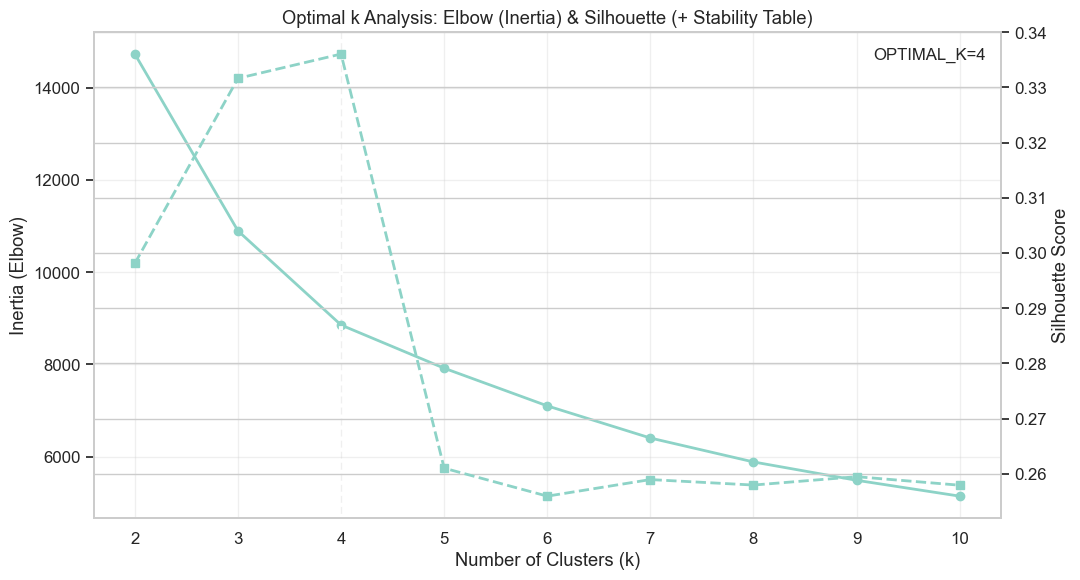

In [11]:
# ==============================================================================
# 3. SCALING & OPTIMAL K SEARCH (Elbow + Silhouette + Stability)
# ==============================================================================
# Select features for clustering
features = ['avg_delay', 'avg_distance', 'log_frequency']
X = df_routes[features]

# Standardize features (Mean=0, Std=1)  ✅ CRITICAL
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------------------------
# 3.1 Evaluate K candidates: Inertia (Elbow) + Silhouette + Stability (ARI)
# ----------------------------------------------------------------------
from sklearn.metrics import adjusted_rand_score
from IPython.display import display

print("Determining optimal number of clusters (k)...")

K_MIN, K_MAX = 2, 10
K_range = range(K_MIN, K_MAX + 1)

BASE_SEED = 42
N_INIT = 10
STABILITY_SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]  # include base for silhouette std

# Silhouette can be expensive on large datasets; sample if needed (set None to disable)
SIL_SAMPLE_SIZE = 10000

rows = []
for k in K_range:
    km_base = KMeans(n_clusters=k, random_state=BASE_SEED, n_init=N_INIT)
    labels_base = km_base.fit_predict(X_scaled)

    # Silhouette (baseline)
    if SIL_SAMPLE_SIZE is not None and X_scaled.shape[0] > SIL_SAMPLE_SIZE:
        sil_base = float(silhouette_score(X_scaled, labels_base, sample_size=SIL_SAMPLE_SIZE, random_state=BASE_SEED))
    else:
        sil_base = float(silhouette_score(X_scaled, labels_base))

    # Stability: ARI vs baseline across multiple seeds (label-permutation invariant)
    aris = []
    sils = [sil_base]
    for s in STABILITY_SEEDS:
        if s == BASE_SEED:
            continue
        km_s = KMeans(n_clusters=k, random_state=s, n_init=N_INIT)
        labels_s = km_s.fit_predict(X_scaled)
        aris.append(float(adjusted_rand_score(labels_base, labels_s)))

        if SIL_SAMPLE_SIZE is not None and X_scaled.shape[0] > SIL_SAMPLE_SIZE:
            sils.append(float(silhouette_score(X_scaled, labels_s, sample_size=SIL_SAMPLE_SIZE, random_state=BASE_SEED)))
        else:
            sils.append(float(silhouette_score(X_scaled, labels_s)))

    mean_ari = float(np.mean(aris)) if len(aris) else np.nan
    std_sil = float(np.std(sils)) if len(sils) else np.nan

    rows.append({
        "k": k,
        "inertia": float(km_base.inertia_),
        "silhouette": sil_base,
        "mean_ari_vs_base": mean_ari,
        "silhouette_std_across_seeds": std_sil
    })

df_k = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
df_k["inertia_reduction_%"] = df_k["inertia"].shift(1).sub(df_k["inertia"]).div(df_k["inertia"].shift(1)).mul(100)

# Choose OPTIMAL_K automatically:
# 1) max silhouette, 2) max stability (ARI), 3) prefer smaller k
df_rank = df_k.sort_values(
    by=["silhouette", "mean_ari_vs_base", "k"],
    ascending=[False, False, True]
).reset_index(drop=True)

OPTIMAL_K = int(df_rank.loc[0, "k"])
best_sil = float(df_rank.loc[0, "silhouette"])

print("\n" + "-"*80)
print("K-SELECTION TABLE (higher silhouette is better; lower inertia is better; higher ARI is more stable)")
print("-"*80)
display(df_k.style.format({
    "inertia": "{:,.2f}",
    "silhouette": "{:.4f}",
    "mean_ari_vs_base": "{:.4f}",
    "silhouette_std_across_seeds": "{:.4f}",
    "inertia_reduction_%": "{:.2f}",
}))
print("-"*80)
print(f"Selected OPTIMAL_K = {OPTIMAL_K} (silhouette={best_sil:.4f})")
print("-"*80)

# ----------------------------------------------------------------------
# 3.2 Plots: Elbow (inertia) + Silhouette (with OPTIMAL_K marker)
# ----------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)')
ax1.plot(df_k["k"], df_k["inertia"], marker='o', linewidth=2)
ax1.axvline(x=OPTIMAL_K, linestyle=':', linewidth=3, label=f'OPTIMAL_K={OPTIMAL_K}')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score')
ax2.plot(df_k["k"], df_k["silhouette"], marker='s', linestyle='--', linewidth=2)

plt.title('Optimal k Analysis: Elbow (Inertia) & Silhouette (+ Stability Table)')
ax1.legend(loc='best')
plt.tight_layout()
plt.show()


In [12]:
# ==============================================================================
# 4. CLUSTERING MODEL (K-Means)
# ==============================================================================
# OPTIMAL_K is selected automatically in Section 3 (Silhouette + Stability).
print(f"Applying K-Means with OPTIMAL_K={OPTIMAL_K}...")
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_routes['cluster'] = kmeans_final.fit_predict(X_scaled)


Applying K-Means with OPTIMAL_K=4...


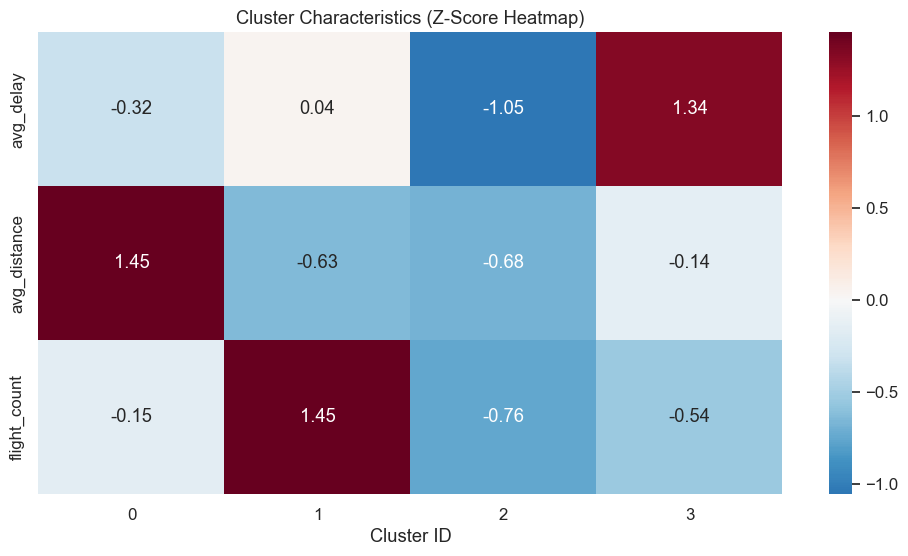

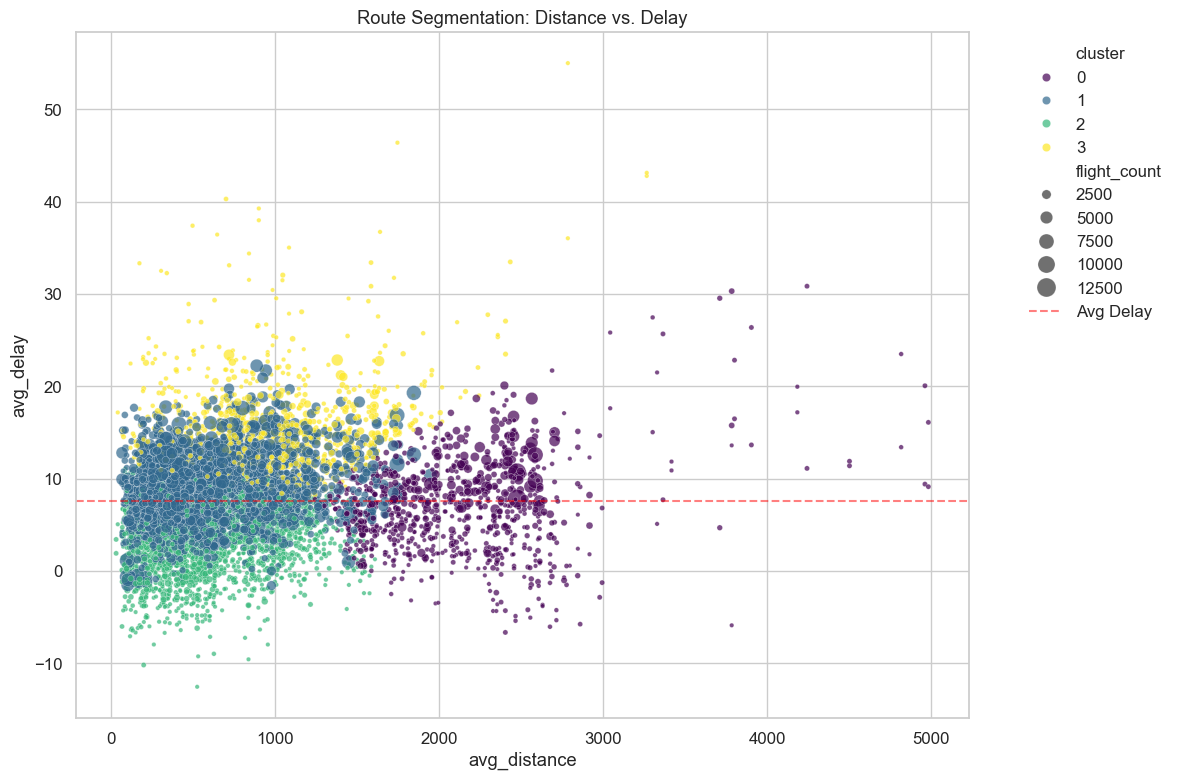

In [13]:
# ==============================================================================
# 5. VISUALIZATION & INTERPRETATION
# ==============================================================================

# 5.1 Cluster Profiling Plot
# Calculate mean values for original features per cluster
cluster_profile = df_routes.groupby('cluster')[['avg_delay', 'avg_distance', 'flight_count']].mean()

# Plot
plt.figure(figsize=(12, 6))
# Normalize for visualization comparison
cluster_profile_norm = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
sns.heatmap(cluster_profile_norm.T, cmap='RdBu_r', center=0, annot=True, fmt='.2f')
plt.title('Cluster Characteristics (Z-Score Heatmap)')
plt.xlabel('Cluster ID')
plt.show()

# 5.2 Scatter Plot: Distance vs Delay (Size = Frequency)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_routes, x='avg_distance', y='avg_delay',
                hue='cluster', palette='viridis', size='flight_count',
                sizes=(10, 200), alpha=0.7)
plt.title('Route Segmentation: Distance vs. Delay')
plt.axhline(y=df_routes['avg_delay'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg Delay')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
# ==============================================================================
# 6. BUSINESS REPORTING (The "Hybrid Strategy" Summary)
# ==============================================================================
print("\n" + "="*80)
print("EXECUTIVE SUMMARY OF FLIGHT ROUTE CLUSTERS")
print("="*80)

# Generate detailed text report
for cluster_id in sorted(df_routes['cluster'].unique()):
    c_data = df_routes[df_routes['cluster'] == cluster_id]

    # Representative Routes (Top 3 by volume)
    top_routes = c_data.nlargest(3, 'flight_count')
    examples = [f"{row['ORIGIN_AIRPORT']}->{row['DESTINATION_AIRPORT']}" for _, row in top_routes.iterrows()]

    print(f"\n CLUSTER {cluster_id}: {len(c_data):,} routes")
    print(f"   • Avg Delay:     {c_data['avg_delay'].mean():5.1f} min")
    print(f"   • Avg Distance:  {c_data['avg_distance'].mean():5.0f} miles")
    print(f"   • Avg Frequency: {c_data['flight_count'].mean():5.0f} flights/year")
    print(f"   • Key Examples:  {', '.join(examples)}")

    # Automated Interpretation Logic
    if c_data['avg_distance'].mean() > 2000:
        label = "LONG HAUL / TRANSCONTINENTAL"
    elif c_data['flight_count'].mean() > 3000:
        label = "HIGH FREQUENCY / SHUTTLE ROUTES"
    elif c_data['avg_delay'].mean() > 15:
        label = "PROBLEM ROUTES (HIGH DELAY)"
    else:
        label = "REGIONAL / LOW DENSITY"
    print(f" INTERPRETATION: {label}")

print("\n" + "="*80)

# Export results
df_routes.to_csv('data/clustered_routes_final.csv', index=False)
print("Results exported to 'clustered_routes_final.csv'")


EXECUTIVE SUMMARY OF FLIGHT ROUTE CLUSTERS

 CLUSTER 0: 915 routes
   • Avg Delay:       7.1 min
   • Avg Distance:   2130 miles
   • Avg Frequency:   615 flights/year
   • Key Examples:  JFK->LAX, LAX->JFK, SFO->JFK
 INTERPRETATION: LONG HAUL / TRANSCONTINENTAL

 CLUSTER 1: 2,427 routes
   • Avg Delay:       9.0 min
   • Avg Distance:    632 miles
   • Avg Frequency:  1763 flights/year
   • Key Examples:  SFO->LAX, LAX->SFO, LAS->LAX
 INTERPRETATION: REGIONAL / LOW DENSITY

 CLUSTER 2: 2,651 routes
   • Avg Delay:       3.4 min
   • Avg Distance:    597 miles
   • Avg Frequency:   185 flights/year
   • Key Examples:  IDA->SLC, BZN->SLC, BUR->SEA
 INTERPRETATION: REGIONAL / LOW DENSITY

 CLUSTER 3: 1,019 routes
   • Avg Delay:      15.5 min
   • Avg Distance:    987 miles
   • Avg Frequency:   337 flights/year
   • Key Examples:  IAH->LAX, ORD->EWR, IAH->SFO
 INTERPRETATION: PROBLEM ROUTES (HIGH DELAY)

Results exported to 'clustered_routes_final.csv'
